Assignment 2 is the coursework 2, which carries 60% of your grades for this module. In this assignment, you will be asked to download a dataset from github and analyse it. ***Everything in this assignment is to be done in Python***.

Similar to assignment  1, you will be asked to explain your code, approach, and results. Unlike assignment 1, many of questions in assignment 2 are open-ended questions, where analysis steps depend on you and how well you understand the problem.

All the Best!<br>Fabricio Ourique


<br>

<div style="padding: 10px; border: 2px solid green;background-color: rgba(200,200,200,0.2);">
This Assignment will be evaluated based on:

* (1) Correctness of code for the given task (i.e., If your code is performing the task correctly)
* (2) Explanation of the logical flow of your code and the results you produced for the task, inclusing Docstring of the fuctions.

Marks for each section and subsections are indicated in the square brackets, such as [2 Marks]

</div>

<br>

<div style="padding: 10px; border: 4px solid red;">
Update your name and QMUL student ID on the top heading, by double clicking it.
</div>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import glob, pickle, os
import IPython

In [ ]:
import zipfile
import os

os.makedirs("data", exist_ok=True)

with zipfile.ZipFile("SpokenNumerals-main.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("Extracted to data/")

Extracted to data/


<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 1. Download data and setup

<!-- <center><font size="5">MLEnd Spoken Numerals Dataset</font></center> -->
<font size="5">MLEnd Spoken Numerals Dataset</font>

**MLEnd Spoken Numerals Dataset** is an open dataset, publicly shared on github. The details about the dataset can be found here: https://MLEndDatasets.github.io/spoken_numerals/. Go to this link and read about the dataset carefully to understand the kind of dataset you will be dealing with.
<br>
<center>
<img src="./images/dataset-cover.jpeg" alt="MLEnd Spoken Numerals Dataset" width=40%/>
<br>
Figure 1: MLEnd Spoken Numerals Dataset  - <a href="https://MLEndDatasets.github.io">https://MLEndDatasets.github.io</a></center>

<div style="padding: 10px; border: 1px solid lightblue;">

<center>
 <span style="align:center; color:blue"> <font size="5">Tip: More you know about your dataset, the better would be your analysis.</font></span>
</center>
</div>

The full dataset can be downloaded in three ways **choose any ONE** of the following options
- **1.1 Using MLEDN python library**  - this might take a long time or might not work due to restrictions, try other options
- **1.2 Download manually (from Github)**
- **1.3 From shared data or link**

After downloading make sure to test if you have all the required dataset by running test blocks in 1.4 section.

### 1.1 Using MLEnd python library

Run the following commands

In [ ]:
try:
    import mlend
    print('='*50)
    print("MLEnd library is already installed and imported")
    print('='*50)
except:
    print("MLEnd library is not installed. Let's install it (need internet connected).")
    os.system("pip install mlend")
    import mlend
    print('='*50)
    print("MLEnd library is now already installed and imported")
    print('='*50)

MLEnd library is already installed and imported


In [ ]:
import mlend
from mlend import download_spoken_numerals, spoken_numerals_load

save_to = './data/'

subset = {}
datadir = download_spoken_numerals(save_to = save_to,
                                   subset = subset,verbose=1,overwrite=False)

In [ ]:
print(f'You data is in directory - {datadir}')

### 1.2 Dowload manually (from Github)

In case, using ```mlend``` library (as explained above in 1.1 section) doesn't work, due to restrictions on download from github, you could download the dataset manually from github link - https://github.com/MLEndDatasets/SpokenNumerals. Go to link and download manually as shown in figure below.

<center>
<img src="./images/download_from_github.png" alt="Download from gith" width=70%/>
<br>
Figure 2: Download dataset from github  - <a href="https://github.com/MLEndDatasets/SpokenNumerals">https://github.com/MLEndDatasets/SpokenNumerals</a>. Click on "Download Zip"</center>
<br>

**IMPORTANT: Store and extract the Downloaded Zip ('SpokenNumerals-main.zip') in ./data folder.**

In this case, your ```datadir``` will be different than section 1.1. It should be as follow:

```python

datadir = './data/SpokenNumerals-main'

```


In [ ]:
datadir = './data/SpokenNumerals-main'

### 1.3 From shared data or link

You could also take the full dataset from someone, who has already downloaded it. Make sure to take the entire dataset and keep it in the data folder.


**IMPORTANT: Store and extract the Downloaded Zip taken from someone ('SpokenNumerals-main.zip') in ./data folder.**

In this case, your ```datadir``` will be different than section 1.1. It should be as follow:

```python

datadir = './data/SpokenNumerals-main'

```

In [ ]:
datadir = './data/SpokenNumerals-main'

### 1.4 Test downloaded dataset:


After you download the dataset, we have to make sure you have all the files is the dataset are in correct location and format.

To test the dataset, run the following code blocks, and if you see no errors, you are good to go to the next sections.

Run the following piece of code to test if you have downloaded and stored data correctly.

Finally, you should have one directory named - `MLEndSND_audiofiles` with 32716 wave files, and at least two CSV files named as `MLEndSND_audio_attributes_benchmark.csv` and `MLEndSND_speakers_demographics_benchmark.csv`

Your file structure should be like as shown below

```python

./data/SpokenNumerals-main

  |- MLEndSND_audiofiles
  |   |- 00000.wav
  |   |- 00001.wav
  |   |   .
  |   |   .
  |
  |- MLEndSND_audio_attributes_benchmark.csv
  |- MLEndSND_speakers_demographics_benchmark.csv

```

#### Test 1

In [ ]:
# Make sure All the required files are in datadir

audio_attribute_file = 'MLEndSND_audio_attributes_benchmark.csv'
speaker_demographic_file = 'MLEndSND_speakers_demographics_benchmark.csv'


CSVFiles = glob.glob(datadir + '/*.csv')
WAVFiles = glob.glob(datadir + '/MLEndSND_audiofiles/*.wav')


assert datadir+'/'+ audio_attribute_file in CSVFiles
assert datadir+'/'+ speaker_demographic_file in CSVFiles
assert len(WAVFiles)==32716

In [ ]:
# Make sure All the required files are in datadir

audio_attribute_file = 'MLEndSND_audio_attributes_benchmark.csv'
speaker_demographic_file = 'MLEndSND_speakers_demographics_benchmark.csv'


CSVFiles = glob.glob(datadir + '/*.csv')
WAVFiles = glob.glob(datadir + '/MLEndSND_audiofiles/*.wav')


assert datadir+'/'+ audio_attribute_file in CSVFiles
assert datadir+'/'+ speaker_demographic_file in CSVFiles
assert len(WAVFiles)==32716

#### Test 2

sampling rate = 22050  shape of x = (33024,)


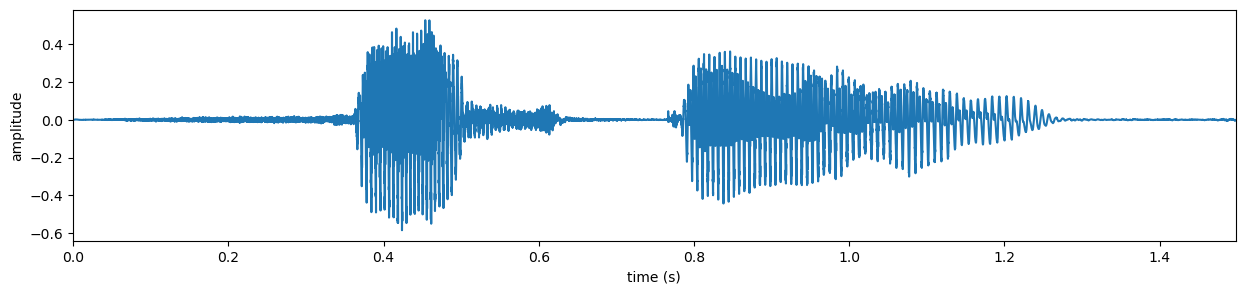

In [ ]:
# Test one audio file

fs, x = scipy.io.wavfile.read(datadir + '/MLEndSND_audiofiles/00003.wav')

print('sampling rate =',fs, ' shape of x =', x.shape)

t = np.arange(len(x))/fs
x = x/(2**15)

plt.figure(figsize=(15,3))
plt.plot(t,x)
plt.xlim([t[0],t[-1]])
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.show()

IPython.display.Audio(x,rate=fs)

<div style="padding: 10px; border: 1px solid green;">

<center>
 <span style="align:center; color:green"> <font size="5"> If you could run the above cell without error, you will see figure of a waveform and an audio player that will produce a sound of word 'fifteen', you are all set-up to go furthur</font></span>
</center>
</div>

If you face error, make sure you have downloaded entire dataset from given link, extracted the compressed folder and renamed folder name to 'data' and keep it in your current folder.

<br>
<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

In [ ]:
glob.glob(datadir + '/*')

### 1.5 Notes on Dataset:

File `MLEndSND_audio_attributes_benchmark.csv`, `MLEndSND_speakers_demographics_benchmark.csv`, and audio file names in `MLEndSND_audiofiles` folder are linked.


* `MLEndSND_audio_attributes_benchmark.csv` file contains attributes of each audio file. So, there should be the same number of rows in `MLEndSND_audio_attributes_benchmark.csv` file as a number of audio files in `MLEndSND_audiofiles` folder.

* In `MLEndSND_audio_attributes_benchmark.csv` file, column named  - 'filename' refers to audio file name in `MLEndSND_audiofiles` folder. Audio file name is a five digit number followed by .wav extension. For example, a wave-file with has filename as  '00007.wav' should have a full path as  filepath = datadir + '/MLEndSND_audiofiles' + filename

* In `MLEndSND_audio_attributes_benchmark.csv` file, column named  - 'Speaker' refer to speaker, which is same as in `MLEndSND_speakers_demographics_benchmark.csv` file.

Example:
  In `MLEndSND_audio_attributes_benchmark.csv` file, third row is

<br>
<center>
<table>
  <tr>
    <th>|</th>
    <th>filename</th>
    <th>Numeral</th>
    <th>Intonation</th>
    <th>Speaker</th>
    <th>Benchmark_A</th>
    <th>Benchmark_B</th>
  </tr>
  <tr>
    <td></td>
    <td>00003.wav</td>
    <td>15</td>
    <td>excited</td>
    <td>107</td>
    <td>Train</td>
    <td>Train</td>
  </tr>
</table>
</center>
  
    
that means, audio file name `00003.wav` has a sound of Numeral '15' spoken by speaker number '107', in 'excited' mood (intonation).

if we look for details of speaker 107 in `MLEndSND_speakers_demographics_benchmark.csv`  file, we will find

  <br>
<center>
  <table>
  <tr>
    <th>|</th>
    <th>Speaker</th>
    <th>Language1</th>
    <th>Language2</th>
    <th>Nationality</th>
    <th>Coordinates</th>
    <th>Benchmark_A</th>
  </tr>
  <tr>
    <td></td>
    <td>107</td>
    <td>Bravanese</td>
    <td>English</td>
    <td>British</td>
    <td>(51.57, -0.07)</td>
    <td>Train</td>
  </tr>
</table>
</center>


 that means speaker 107 has British nationality, with first language as Bravanese and second language as English.



For this module and assignment, we will ignore the Benchmark columns in both files.
  
***It is recommended that you read the dataset description carefully from the given link.***

<div style="padding: 10px; border: 1px solid green;">

<center>
 <span style="align:center; color:green"> <font size="5">Your assignment work, which will be evaluated starts from here onwards</font></span>
</center>
</div>

## 2. Read files and summarise the data [3 Marks]

After downloading dataset, you should have all the audio files in `MLEndSND_audiofiles` folder and two CSV files explaining the attributes of audio files and speakers.

Two CSV files in dataset are
 - `MLEndSND_speakers_demographics_benchmark.csv` and
 - `MLEndSND_audio_attributes_benchmark.csv`

<br>

<div style="padding: 10px; border: 4px dashed black;">

**Q2.1:**
    
* Create a list of all audio files as their full path (use ```file_list = glob.glob(path)```).
* Read both CSV files (as listed above) and summarise the dataset.

    Summarising the dataset here means tabulating the number of audio files you have in the dataset for different speakers, numerals, nationalities and intonations. You could add an additional summary about the dataset too.
    
    
    * **Create tables and write your explanations in a given box**.
    
    
</div>

## Q2.1

In [ ]:
audio_path = os.path.join(datadir, "MLEndSND_audiofiles", "*.wav")
file_list = sorted(glob.glob(audio_path))

attributes_path = os.path.join(datadir, "MLEndSND_audio_attributes_benchmark.csv")
demographics_path = os.path.join(datadir, "MLEndSND_speakers_demographics_benchmark.csv")

audio_attributes = pd.read_csv(attributes_path)
speaker_demographics = pd.read_csv(demographics_path)

print("Number of audio files found:", len(file_list))
print("Audio attributes shape:", audio_attributes.shape)
print("Speaker demographics shape:", speaker_demographics.shape)

display(audio_attributes.head())
display(speaker_demographics.head())

Number of audio files found: 32716
Audio attributes shape: (32654, 6)
Speaker demographics shape: (154, 6)


,filename,Numeral,Intonation,Speaker,Benchmark_A,Benchmark_B
0,00000.wav,3,excited,59,Train,Test
1,00001.wav,1000000,question,31,Train,Test
2,00003.wav,15,excited,107,Train,Train
3,00004.wav,13,excited,114,Train,Test
4,00005.wav,19,neutral,132,Train,Train


,Speaker,Language1,Language2,Nationality,Coordinates,Benchmark_A
0,0,German,NaN,German,"(52.52, 13.40)",Test
1,1,Chinese,NaN,Chinese,"(51.52,-0.04)",Test
2,2,Hindi,English,Indian,"(26.82, 75.62)",Train
3,3,NaN,NaN,NaN,NaN,Test
4,4,Urdu,English,Indian,"(51.52, -0.04)",Test


In this section, I will summarise the data in both the speaker demographics csv and audio attributes csv. The attributes csv includes descriptions relating to the recording for example the audio speaker, filename and numeral. The demographic csv contains information about the speaker for example the speakers nationality and language. To gain insight into the data I am using I used glob to load the data and make a list of all the audio files. The results show us that there are 32,654 rows and 6 columns in the audio attributes csv whereas the speaker demographic csv only has 154 rows and 6 columns.

In [ ]:
def find_column(df, possible_names):
    """
    Finds a column in a DataFrame by comparing lowercase column names.

    Parameters
    df : pandas.DataFrame
        The DataFrame to search.
    possible_names : list[str]
        Possible exact or partial names for the required column.

    Returns
    str
        The matching column name from the DataFrame.
    """
    lower_to_original = {c.lower().strip(): c for c in df.columns}

    for name in possible_names:
        if name.lower() in lower_to_original:
            return lower_to_original[name.lower()]

    for col in df.columns:
        col_lower = col.lower().strip()
        for name in possible_names:
            if name.lower() in col_lower:
                return col

    raise ValueError(f"Could not find any of these columns: {possible_names}. Available columns: {list(df.columns)}")


filename_col = find_column(audio_attributes, ["filename", "file", "audio file", "file_name"])
speaker_col = find_column(audio_attributes, ["speaker", "speaker_id", "speaker number", "speaker_number"])
numeral_col = find_column(audio_attributes, ["numeral", "number", "digit"])
intonation_col = find_column(audio_attributes, ["intonation", "tone"])

print("Detected columns:")
print("filename:", filename_col)
print("speaker:", speaker_col)
print("numeral:", numeral_col)
print("intonation:", intonation_col)

Detected columns:
filename: filename
speaker: Speaker
numeral: Numeral
intonation: Intonation


Now that I have summarised the number of audio files and both csv file shapes, I used the function ‘def find_column (df, possible_names):’ to find the right name for each column. The docstring I incorporated allows us to see both lowercase and uppercase column names. This is evident in the results as the columns speaker, numeral and intonation were displayed in uppercase. Overall, this section was able to efficiently present the right column names.

In [ ]:
speaker_summary = audio_attributes[speaker_col].value_counts().sort_index().reset_index()
speaker_summary.columns = ["speaker", "number_of_audio_files"]

numeral_summary = audio_attributes[numeral_col].value_counts().sort_index().reset_index()
numeral_summary.columns = ["numeral", "number_of_audio_files"]

intonation_summary = audio_attributes[intonation_col].value_counts().reset_index()
intonation_summary.columns = ["intonation", "number_of_audio_files"]

try:
    nationality_col = find_column(speaker_demographics, ["nationality", "country", "native language"])
    nationality_summary = speaker_demographics[nationality_col].value_counts().reset_index()
    nationality_summary.columns = ["nationality", "number_of_speakers"]
except ValueError:
    nationality_col = None
    nationality_summary = pd.DataFrame({"message": ["No nationality-like column found"]})

display(speaker_summary.head(10))
display(numeral_summary)
display(intonation_summary)
display(nationality_summary.head(10))

,speaker,number_of_audio_files
0,0,217
1,1,224
2,2,218
3,3,203
4,4,217
5,5,203
6,6,209
7,7,214
8,8,207
9,9,227


,numeral,number_of_audio_files
0,0,985
1,1,1012
2,2,1010
3,3,1028
4,4,1034
5,5,1003
6,6,1013
7,7,1020
8,8,1035
9,9,1021


,intonation,number_of_audio_files
0,excited,8223
1,question,8202
2,neutral,8187
3,bored,8042


,nationality,number_of_speakers
0,Indian,43
1,British,37
2,Chinese,18
3,Pakistani,5
4,Saudi Arabian,3
5,Hong Kong,3
6,Nigerian,3
7,Dutch,2
8,Portuguese,2
9,Greek,2


In this section I have completed additional summary about the dataset. The first summary displays how many audio files belong to each speaker. The results show all speakers have between 203 to 227 audio files, which indicates a balanced data set across the speakers. The next summary shows us how many audio files belong to each numeral. For example, Numeral 90 has the most audio files (1062), while Numeral 10 has the fewest (975). The data set is balanced as majority of the numerals have audio files slightly below or above 1,000. The dataset shows the intonation types excited, question, neutral and bored. The results are very similar with the audio files counts ranging between 8, 042 to 8,223. Lastly, I summarised the data from the speaker demographic csv files to find the nationality of the speakers in the dataset. I found Indian (43) and British (37) to be the most number of speakers in the dataset and Dutch (2), Portuguese (2) and Greek (2) with the lowest number of speakers.


<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 3. Select data of your assigned speaker and summarise [3 Marks]

Out of 32654 audio files, you will be working on audio files of only one speaker. Your speaker is the last two digits of your QMUL Student ID.

If your ID is 260056649 your speaker is 49

Your assigned speaker number is 49, change the value of My_speaker as follows:

```python

My_speaker = 49

```
<br>

<div style="padding: 10px; border: 4px dashed black;">

* **Q3.1:** Extract the attributes of audio files from `MLEndSND_audio_attributes_benchmark.csv` which belong to your assigned speaker and summarise the data in a similar fashion as Q2.1.

</div>

## Q3.1

In [ ]:
My_speaker = 3

speaker_data = audio_attributes[audio_attributes[speaker_col].astype(str) == str(My_speaker)].copy()

print("Selected speaker:", My_speaker)
print("Number of recordings for selected speaker:", len(speaker_data))

display(speaker_data.head())

speaker_numeral_summary = speaker_data[numeral_col].value_counts().sort_index().reset_index()
speaker_numeral_summary.columns = ["numeral", "number_of_audio_files"]

speaker_intonation_summary = speaker_data[intonation_col].value_counts().reset_index()
speaker_intonation_summary.columns = ["intonation", "number_of_audio_files"]

display(speaker_numeral_summary)
display(speaker_intonation_summary)

try:
    demo_speaker_col = find_column(speaker_demographics, ["speaker", "speaker_id", "speaker number", "speaker_number"])
    display(speaker_demographics[speaker_demographics[demo_speaker_col].astype(str) == str(My_speaker)])
except Exception as e:
    print("Could not display demographics for this speaker:", e)

Selected speaker: 3
Number of recordings for selected speaker: 203


,filename,Numeral,Intonation,Speaker,Benchmark_A,Benchmark_B
97,00155.wav,1,excited,3,Test,Train
137,00213.wav,2,excited,3,Test,Test
403,00596.wav,10,bored,3,Test,Train
495,00738.wav,8,neutral,3,Test,Train
596,00874.wav,1000000,bored,3,Test,Test


,numeral,number_of_audio_files
0,0,4
1,1,8
2,2,6
3,3,7
4,4,7
5,5,7
6,6,5
7,7,6
8,8,6
9,9,6


,intonation,number_of_audio_files
0,excited,53
1,question,53
2,bored,49
3,neutral,48


,Speaker,Language1,Language2,Nationality,Coordinates,Benchmark_A
3,3,NaN,NaN,NaN,NaN,Test


In this section of the project, I selected the assignment speaker for the data and summarised it. The last two numbers in my QMUL Student ID ends with 03. Instead I used 3 as my speaker as Python causes a syntax error when the integer starts with 0. The audio attributes are filtered so that the speaker columns equals 3. The results show 203 audio recordings in the dataset for my speaker (3). The first table below shows us a several audio files for speaker 3, which includes the numeral, filename, intonation, speaker, both benchmarks A and B. Once I confirmed the dataset is filtered to my specific speaker, I then summarised the numeral and intonation for speaker 3. The results for numeral show us that the number of audio files range between 4 to 8. The intonation table shows that question excited have the most with 53 audio files whereas neutral has the least count number with 48 audio files. Lastly, I used the function ‘find_column’ once again to show me details from speaker 3 in the demographics csv. The results present languages, nationality and coordinates as NaN, which indicates some of the data for speaker 3 is not available or could be missing.

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 4. Compute features of audio files of your selected speaker [27 Marks]

### 4.1 Read and clean audio files [2 Mark]

<div style="padding: 10px; border: 4px dashed black;">
    
**Q4.1A:** Create a function that takes a filename (as it is in `MLEndSND_audio_attributes_benchmark.csv`), reads the respective audio file and returns sampling rate `fs` and audio samples as `x`.

Example: if filename is 00003.wave, then path of audio file is
             path = datadir + '/MLEndSND_Public/00003.wav'


Process your audio samples x with the following cleaning steps:

* Divide x with 2^15 to covert integer type to float values of x (check section 1.1 test function)

* Some of the audio files will have 2-channel recording, which will return an array of many rows and 2 columns. Each column is one channel. If an audio file you are reading has 2-channels, select the first column only and return x.
    


**An empty code function is given in cell below.**
    
</div>

In [ ]:
def read_audio_file(filename="00003.wav"):
    """
    Read one audio file from the MLEnd Spoken Numerals dataset and return a clean mono signal.

    Parameters:

    filename : str
        Audio filename, '00003.wav'. It can be either a basename or a full path.

    Returns:

    fs : int
        Sampling frequency of the audio file.
    x : numpy.ndarray
        One-dimensional audio signal as float values scaled between -1 and 1.
    """
    fname = os.path.basename(str(filename))
    path = filename if os.path.exists(str(filename)) else os.path.join(datadir, "MLEndSND_audiofiles", fname)

    fs, x = scipy.io.wavfile.read(path)

    if x.ndim == 2:
        x = x[:, 0]

    x = x.astype(float)

    if np.max(np.abs(x)) > 1:
        x = x / (2**15)

    return fs, x

In this section, the function I used is ‘def read_audio_file ’ and the following text in red is the docstring. I used scipy to read the audio recordings, fs is the sampling rate and x is the audio sample. When the value in the dataset presents as an integer I divided x with 2^15 to change the value into a float. As some audio files have two channels I only used the first channel. Over, I successfully prepared the data for feature extraction by reading the audio recordings and cleaning sampling rate and audio signal. In the test phase I plotted the audio waveform and I was able to successfully run the audio cell without any errors.

#### 4.1 Tests

The implementations of my functions are correct and present no errors, press the below start button or cell to confirm this.

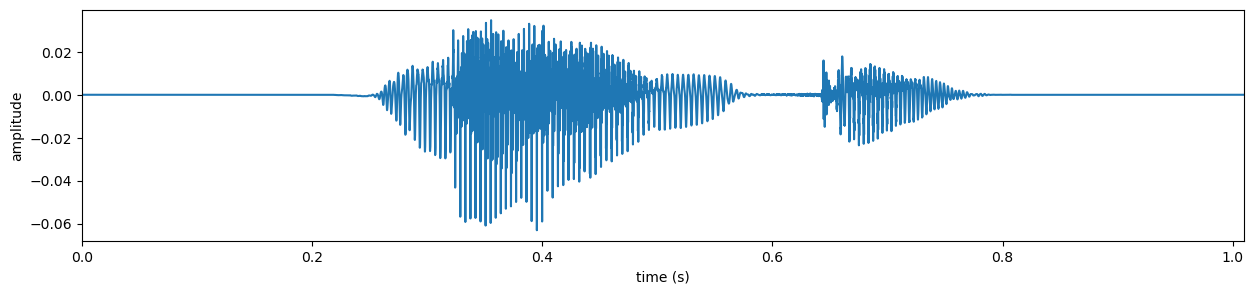

In [ ]:
fs, x = read_audio_file(filename = '06801.wav')

assert x.ndim==1
assert x.dtype==float
assert np.max(np.abs(x))<=1


t = np.arange(len(x))/fs
plt.figure(figsize=(15,3))
plt.plot(t,x)
plt.xlim([t[0],t[-1]])
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.show()

IPython.display.Audio(x,rate=fs)

<div style="padding: 3px; border: 2px solid green;">

<center>
 <span style="align:center; color:green"> <font size="3"> If you could run the above cell without error, your implementations of functions are correct.</font></span>
</center>
</div>

<br>

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

### 4.2 Extract silence and non-silence part of audio [9 Marks]

Before analysing audio files, you will need to extract the silence and non-silence parts. In this part of the section, you have to write a function that extracts the segments of silence and non-silence parts of the given audio file.

<br>

<div style="padding: 10px; border: 4px dashed black;">
    
**Q4.2A:** **Design your own approach** to extract the silence and non-silence parts of audio recording. Write a function that takes sample array x, and sampling rate fs and returns the silence and non-silence parts of audio.

You need to explain your approach and logic to extract the silence and non-silence parts. **DO NOT** use any signal processing libraries that extract the silence and non-silence parts of audio automatically, otherwise the marks for this part of the assignment will be **ZERO**.
    
</div>


#### Explanation - Silence/Non-silence parts

If you observe the recording waveforms by listening to it or plotting it, you will notice some parts of it where speaker is silent (not speaking anything). That part of audio is called as silence parts and rest is called non-silence part. An example of audio file is shown below (Figure 3), where silent parts of the audio are where the amplitude of samples (intensity) is very low.

<img src="./images/audio_silence_non_silence.png" alt="Silence and Non-silence parts of audio" width=100%/>
<br>
<center>Figure 3: Silence and Non-silence parts of audio file</center>


You are encouraged to explore the idea and theory behind it and create your own logic. It might not be perfect, but that is okay. To test your function, try several audio files from the dataset. Plot them by highlighting the silence and non-silence part.

**An example of plotting vertical lines on a waveform to show silence and non-silence parts is here.**

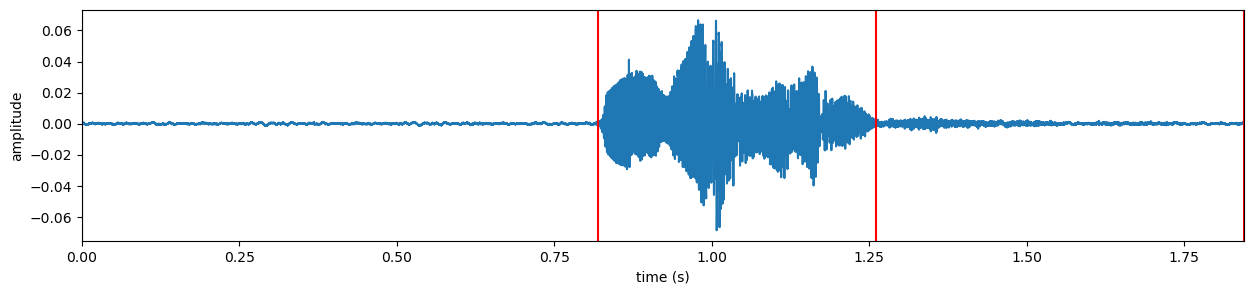

In [ ]:
fs, x = scipy.io.wavfile.read(datadir + '/MLEndSND_audiofiles/00001.wav')
t = np.arange(len(x))/fs
x = x/(2**15)


silence_idx1_start = 0
silence_idx1_end   = 18083

silence_idx2_start = 27798
silence_idx2_end = len(x)-1


plt.figure(figsize=(15,3))
plt.plot(t,x)
plt.xlim([t[0],t[-1]])
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.axvline(t[silence_idx1_start],color='r')
plt.axvline(t[silence_idx1_end],color='r')

plt.axvline(t[silence_idx2_start],color='r')
plt.axvline(t[silence_idx2_end],color='r')
plt.show()

#### Q4.2

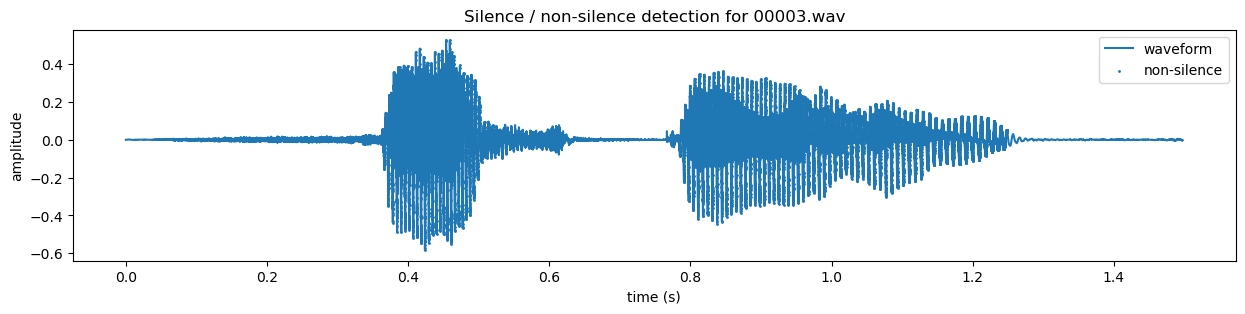

(array([-0.00048828, -0.00064087, -0.00030518, ..., -0.00112915,
        -0.00125122, -0.00183105]),
 array([-0.00082397, -0.00106812, -0.00476074, ...,  0.04266357,
         0.04159546,  0.04046631]))

In [ ]:
def extract_silence_non_silence(x, fs, frame_ms=20, threshold_ratio=0.12):
    """
    Split an audio signal into silence and non-silence samples using an amplitude envelope.

    Approach:
    1. Compute the absolute amplitude of the signal.
    2. Smooth it with a short moving-average window.
    3. Mark samples as non-silence when the smoothed amplitude is above an adaptive threshold.
    4. Everything below the threshold is treated as silence.

    Parameters:
    x : numpy.ndarray
        One-dimensional audio signal.
    fs : int
        Sampling frequency.
    frame_ms : int
        Smoothing window length in milliseconds.
    threshold_ratio : float
        Fraction of the maximum envelope used as the silence threshold.

    Returns:
    silence : numpy.ndarray
        Samples classified as silence.
    non_silence : numpy.ndarray
        Samples classified as speech/non-silence.
    silence_mask : numpy.ndarray
        Boolean mask where True means silence.
    non_silence_mask : numpy.ndarray
        Boolean mask where True means non-silence.
    """
    x = np.asarray(x, dtype=float)

    if len(x) == 0:
        empty_mask = np.array([], dtype=bool)
        return x, x, empty_mask, empty_mask

    window = max(1, int(fs * frame_ms / 1000))
    envelope = np.convolve(np.abs(x), np.ones(window) / window, mode="same")

    threshold = max(0.005, threshold_ratio * np.max(envelope))
    non_silence_mask = envelope > threshold
    silence_mask = ~non_silence_mask

    silence = x[silence_mask]
    non_silence = x[non_silence_mask]

    return silence, non_silence, silence_mask, non_silence_mask


def plot_silence_detection(filename):
    """
    Plot a waveform and highlight detected non-silence samples for visual checking.
    """
    fs, x = read_audio_file(filename)
    silence, non_silence, silence_mask, non_silence_mask = extract_silence_non_silence(x, fs)
    t = np.arange(len(x)) / fs

    plt.figure(figsize=(15, 3))
    plt.plot(t, x, label="waveform")
    plt.scatter(t[non_silence_mask], x[non_silence_mask], s=1, label="non-silence")
    plt.xlabel("time (s)")
    plt.ylabel("amplitude")
    plt.title(f"Silence / non-silence detection for {filename}")
    plt.legend()
    plt.show()

    return silence, non_silence


plot_silence_detection("00003.wav")

This section of the project uses my own approach to extract non silent and silent sections of the audio file. The function I used it ‘def extract_silence_non_silence’, which includes x, fs, frame_ms and threshold_ratio. After separating both parts of the audio I then used an amplitude method in my approach to compare the waveform for silent and non silent audio. Also using NumPy to change the audio into an array. ‘Np.abs (x)’ was then used to find the absolute value and moving average window is used to smooth it. As you can see from the plot shows a visual of the waveform where higher waveforms represent non silent and lower waveforms represent silent audios. Signal processing libraries where not used but numpy was the library used to preform calculations. Although this method is not flawless, it is comprehensible and appropriate for comparing recordings in this project. The plot is a visual representation of the silence part and non silence parts of the audio and there intensities.

### 4.3 Compute features of audio file [16 Marks]

<div style="padding: 10px; border: 4px dashed black;">

**Q4.3**: For given array of sample values from audio file as x, and sampling rate as fs, write the code for following functions.

* **Q4.3A:** Function to compute the duration of silence and duration of non-silence part of audio file. [4 MARKS]
* **Q4.3B:** Function to compute the energy of silence and non-silence part of audio file. [4 MARKS]
* **Q4.3C:** Function to compute the mean and standard deviation of                        [4 MARKS]
  * positive values of samples in array x.
  * negative values of samples in array x.
* **Q4.3D:** Function to compute zero-crossing rate of silence and non-silence part of audio file. [4 MARKS]
    
    
**For each, DO write the proper docstring, explaining your approach, input and output of the function.**
    
</div>

After completing above five functions, you will have total 10 features for an audio file, which are tabulated below.

<center>
    <caption><b>Table 1: List of features</b></caption>
<table>
  <tr>
    <th>SN</th>
    <th>Feature</th>
    <th></th>
  </tr>
  <tr>
    <td>1</td>
    <td>Duration of silence part</td>
    <td></td>
  </tr>
  <tr>
    <td>2</td>
    <td>Energy of silence part</td>
    <td></td>
  </tr>
    <tr>
    <td>3</td>
    <td>Zero-crossing of silence part</td>
    <td></td>
  </tr>
  <tr>
    <td>4</td>
    <td>Duration of non-silence part</td>
    <td></td>
  </tr>
  <tr>
    <td>5</td>
    <td>Energy of non-silence part</td>
    <td></td>
  </tr>
   <tr>
    <td>6</td>
    <td>Zero-crossing of non-silence part</td>
    <td></td>
  </tr>
     <tr>
    <td>7</td>
    <td>Mean of positive values of x</td>
    <td></td>
  </tr>
       <tr>
    <td>8</td>
    <td>Standard Deviation of positive values of x</td>
    <td></td>
  </tr>
       <tr>
    <td>9</td>
    <td>Mean of negative values of x</td>
    <td></td>
  </tr>
       <tr>
    <td>10</td>
    <td>Standard Deviation  of negative values of x</td>
    <td></td>
  </tr>
</table>  
</center>

#### Explanation of audio features

Some of the audio features in questions are explained here.

#### Duration of audio file:

Duration of audio file in seconds can be computed by using the sampling rate (fs). Sampling rate, fs, tells us how many samples were recorded in one second. For example, if the sampling rate is 100, and we have 1000 sample values in x array, then following the logic, we could compute that the duration of this audio file us 1000/100 =  10 seconds.


#### Energy of audio signal:

The energy of an audio signal, or energy of a signal in general is computed as follows.


$$E_x = \sum_{i=0}^{N-1} x(i)^2$$


which means, a sum of squared values of x.



#### Zero-crossing rate:

Zero-crossing rate is a common attribute computed for a signal, especially for sound and audio signals. It  is computed as how many times the signal crosses the zero-line divided by the length of signal. In other words, how many times, the amplitude of signal go from + (positive values) to - (negative values) or - (negative values) to + (positive values).

Example:

if a signal $x = [0.1, 0.3, -0.1, -0.3, 0.1, 0.5, 0.8. -0.5]$, then we can see, signal x cross zero line 3 times:

    * First, from 0.3 to -0.1,
    * Second, from -0.3 to 0.1, and
    * Third, from 0.8 to -0.5
    
Since, length of x in this example is 8, zero-crossing rate of x is 3/8 = 0.375

#### Q4.3A

In [ ]:
def duration_features(x, fs):
    """
    Compute duration of silence and non-silence parts of an audio signal.

    Parameters:
    x : numpy.ndarray
        Audio samples.
    fs : int
        Sampling frequency.

    Returns:
    silence_duration : float
        Duration of samples classified as silence, in seconds.
    non_silence_duration : float
        Duration of samples classified as non-silence, in seconds.
    """
    silence, non_silence, _, _ = extract_silence_non_silence(x, fs)
    silence_duration = len(silence) / fs
    non_silence_duration = len(non_silence) / fs
    return silence_duration, non_silence_duration

I'll be computing the duration of the audio files' silent and non-silence segments in this question. Using my threshold function, I first separated the audio into silence and non-silence. The number of samples for both silent and non-silence segments is then divided by the sampling frequency (fs) to determine the duration. This is enabled because the sampling frequency indicates the number of samples that take place every second.

#### Q4.3B

In [ ]:
def energy_features(x, fs):
    """
    Compute energy of silence and non-silence parts of an audio signal.

    Energy is calculated as the sum of squared sample amplitudes.

    Parameters
    ----------
    x : numpy.ndarray
        Audio samples.
    fs : int
        Sampling frequency.

    Returns
    -------
    silence_energy : float
        Energy of the silence part.
    non_silence_energy : float
        Energy of the non-silence part.
    """
    silence, non_silence, _, _ = extract_silence_non_silence(x, fs)
    silence_energy = float(np.sum(silence ** 2))
    non_silence_energy = float(np.sum(non_silence ** 2))
    return silence_energy, non_silence_energy

In this section, I will calculate the energy of the audio file's silent and non-silence portions. The sum of squared amplitudes is used to determine energy. For the silent and non-silence arrays, I computed this independently. Since the spoken numeral is included in the non-silence portion, it should have more energy than the silent portion, which should primarily consist of background noise.

#### Q4.3C

In [ ]:
def positive_negative_stats(x):
    """
    Compute mean and standard deviation of positive and negative sample values.

    Parameters:
    x : numpy.ndarray
        Audio samples.

    Returns:
    pos_mean : float
        Mean of positive sample values.
    pos_std : float
        Standard deviation of positive sample values.
    neg_mean : float
        Mean of negative sample values.
    neg_std : float
        Standard deviation of negative sample values.
    """
    x = np.asarray(x, dtype=float)
    positive = x[x > 0]
    negative = x[x < 0]

    pos_mean = float(np.mean(positive)) if len(positive) else 0.0
    pos_std = float(np.std(positive)) if len(positive) else 0.0
    neg_mean = float(np.mean(negative)) if len(negative) else 0.0
    neg_std = float(np.std(negative)) if len(negative) else 0.0

    return pos_mean, pos_std, neg_mean, neg_std

I will calculate the mean and standard deviation of samples in x that have negative and positive values in question 4C. I divided the signal into two categories: positive and negative. Next, I calculated each group's mean and standard deviation. The average size and dispersion of the waveform above and below zero are described by these values.

#### Q4.3D

In [ ]:
def zero_crossing_rate(signal):
    """
    Compute the zero-crossing rate of a signal.

    Parameters:
    signal : numpy.ndarray
        Input signal.

    Returns:
    float
        Number of sign changes divided by the signal length.
    """
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 2:
        return 0.0

    signs = np.sign(signal)
    signs[signs == 0] = 1
    crossings = np.sum(signs[1:] != signs[:-1])
    return float(crossings / len(signal))


def zero_crossing_features(x, fs):
    """
    Compute zero-crossing rates for silence and non-silence parts.

    Parameters:
    x : numpy.ndarray
        Audio samples.
    fs : int
        Sampling frequency.

    Returns:
    silence_zcr : float
        Zero-crossing rate of silence samples.
    non_silence_zcr : float
        Zero-crossing rate of non-silence samples.
    """
    silence, non_silence, _, _ = extract_silence_non_silence(x, fs)
    silence_zcr = zero_crossing_rate(silence)
    non_silence_zcr = zero_crossing_rate(non_silence)
    return silence_zcr, non_silence_zcr


def compute_10_features(filename):
    """
    Compute all 10 required audio features for one file.

    Returns
    -------
    list[float]
        The 10 features in the same order as Table 1.
    """
    fs, x = read_audio_file(filename)

    silence_duration, non_silence_duration = duration_features(x, fs)
    silence_energy, non_silence_energy = energy_features(x, fs)
    pos_mean, pos_std, neg_mean, neg_std = positive_negative_stats(x)
    silence_zcr, non_silence_zcr = zero_crossing_features(x, fs)

    return [
        silence_duration,
        silence_energy,
        silence_zcr,
        non_silence_duration,
        non_silence_energy,
        non_silence_zcr,
        pos_mean,
        pos_std,
        neg_mean,
        neg_std
    ]

In question 4D, I will calculate the zero-crossing rate of the audio file's non-silence and quiet portions. The frequency with which the signal changes sign is measured by the zero-crossing rate. I calculated the number of sign changes and divided it by the signal's duration. For both quiet and non-silence, this was done independently. This feature can be useful for comparing audio files because speech frequently has a distinct zero-crossing pattern than background silence.

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 5. Analyse audio files of your speaker [23 Marks]

Now that you have functions to compute different features/characteristics of an audio file, you are ready to analyse the audio files of your assigned speakers.


### 5.1 Extract features [5 Marks]
<br>

<div style="padding: 10px; border: 4px dashed black;">
    
**Q5A**: Extract the list of all the filenames of the speaker assigned to you, read the audio file, and compute all the 10 features listed in Table 1 in Section 4.3. Use your functions from section 4. Save all the 10 features of audio files in an array.

</div>

### 5.2 Save features in CSV file [5 Marks]
<br>
Once you have computed all the 10 features of all the audio files of your speaker, do the following:

<br>
    
<div style="padding: 10px; border: 4px dashed black;">

**Q5B**: Create a Pandas DataFrame, that lists all the 10 features of each audio file of your speaker. Save this DataFrame as CSV file with name as **'Speaker_[YOUR SPEAKER NUMBER]_Audio_features.csv'**,
    
* If you have 500 audio files from your speaker, this DataFrame should have 500 rows and 11 columns. The first column named as file name and the other 10 columns as 10 features.
* Make sure to have appropriate headings (column names) in your DataFrame
* While saving DataFrame as CSV, make sure to name it correctly as 'Speaker_[YOUR SPEAKER NUMBER]_Audio_features.csv'. For example, if your speaker number is 200, then the filename should be 'Speaker_200_Audio_features.csv'
* **Make sure to attach this CSV with your submission.**
</div>



### 5.3 Analyse your speaker [8 Marks]
<br>


<div style="padding: 10px; border: 4px dashed black;">
    
**Q5C**: Compute the statistics (mean, median, standard deviation, minimum, and maximum) of duration, energy, and zero-crossing for non-silence part of all the audios of your speaker. Display as table and explain your results.
    
</div>


### 5.4 Compare Bored and Excited Intonations [5 Marks]
<br>

<div style="padding: 10px; border: 4px dashed black;">
    
**Q5D**: Compute the mean and standard deviation of all the 10 features for 'bored' and 'excited' category of your speaker for *numeral 1* only. Plot them for comparative analysis and explain the results.
    
* In file - `MLEndSND_audio_attributes_benchmark.csv`, each audio file has intonation - bored, excited, neutral, and question. Select audio files of YOUR SPEAKER ONLY with numeral 1 and compute statistics of audio files with intonation labelled as bored and intonation labelled as excited. Plot them to compare and explain the comparative results.
</div>

### Q5A

In [ ]:
feature_columns = [
    "silence_duration",
    "silence_energy",
    "silence_zcr",
    "non_silence_duration",
    "non_silence_energy",
    "non_silence_zcr",
    "positive_mean",
    "positive_std",
    "negative_mean",
    "negative_std"
]

speaker_filenames = speaker_data[filename_col].astype(str).tolist()

speaker_features = []
for filename in speaker_filenames:
    try:
        features = compute_10_features(filename)
        speaker_features.append([os.path.basename(filename)] + features)
    except Exception as e:
        print(f"Skipping {filename}: {e}")

print("Number of feature rows:", len(speaker_features))

/tmp/ipykernel_225/3310566983.py:20: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = scipy.io.wavfile.read(path)


Number of feature rows: 203


In this section, I made a list named feature column which includes all 10 audio features from section 4.3. I created speaker feature to keep the features for all the audio recordings. The computation ‘compute_10_feature (filename)’ was used to calculate each one of the 10 features. As seen in the code except and try was used to avoid errors and delays in the process. The results show that there is 203 feature rows that was extracted and they all belong to speaker 3.

### Q5B

In [ ]:
speaker_feature_df = pd.DataFrame(
    speaker_features,
    columns=["filename"] + feature_columns
)

speaker_feature_path = f"Speaker_{My_speaker}_Audio_features.csv"
speaker_feature_df.to_csv(speaker_feature_path, index=False)

display(speaker_feature_df.head())
print("Saved:", speaker_feature_path)

,filename,silence_duration,silence_energy,silence_zcr,non_silence_duration,non_silence_energy,non_silence_zcr,positive_mean,positive_std,negative_mean,negative_std
0,00155.wav,0.713152,3.157669,0.111542,0.273696,571.010158,0.053687,0.067294,0.141136,-0.070089,0.154622
1,00213.wav,0.799365,2.392770,0.107171,0.303583,577.616618,0.131013,0.067253,0.133481,-0.067213,0.145881
2,00596.wav,1.193968,0.700612,0.715843,0.315329,114.311960,0.179347,0.050837,0.067777,-0.019603,0.063345
3,00738.wav,0.715964,0.131336,0.008868,0.247664,73.762834,0.099799,0.053215,0.062508,-0.047775,0.087306
4,00874.wav,0.860816,0.018911,0.690480,0.485941,27.922419,0.076248,0.030243,0.030453,-0.014089,0.029558


Saved: Speaker_3_Audio_features.csv


In this section, I used Pandas Data Frame to create a list of each of the 10 features from the audio file, this can be seen in the function ‘speaker_feature_df.to_csv’. As seen in the table and attached csv file there are 11 column in total. The csv was correctly named and saved as ‘Speaker_3_Audio_feature.csv’.

### Q5C

In [ ]:
selected_non_silence_features = [
    "non_silence_duration",
    "non_silence_energy",
    "non_silence_zcr"
]

q5c_stats = speaker_feature_df[selected_non_silence_features].agg(
    ["mean", "median", "std", "min", "max"]
).T

display(q5c_stats)

,mean,median,std,min,max
non_silence_duration,0.408791,0.405329,0.099270,0.197982,0.705760
non_silence_energy,398.292658,305.517421,317.631243,15.389854,1488.373577
non_silence_zcr,0.102737,0.096088,0.055869,0.020502,0.271973


The following table presents the non silence duration, zero crossing rate and energy for speaker 3. The mean gives the average across the audio files and median is key as it is not affected by major values. The standard deviation presents the variation in the speaker's audio file. Maximum and minimum counts identify loud, quiet, short or long recordings. As there is several spoken audios, the silence energy is expected to be lower than the non silence energy. The over mean results for non silence show 0.408 for duration, 398.292 for energy and 0.102 for zero crossing rate.

### Q5D

silence_duration           silence_energy           silence_zcr  \
                       mean       std           mean       std        mean   
Intonation                                                                   
bored              0.893265  0.429619       0.459116  0.240503    0.600006   
excited            0.710159  0.004233       3.347612  0.268619    0.103645   

                     non_silence_duration           non_silence_energy  \
                 std                 mean       std               mean   
Intonation                                                               
bored       0.038746             0.354807  0.054741         216.482326   
excited     0.011168             0.288299  0.020652         724.001830   

                       non_silence_zcr           positive_mean            \
                   std            mean       std          mean       std   
Intonation                                                                 
bored         5.235947        0.055505  0.007886      0.080668  0.005972   
excited     216.362897        0.051099  0.003660      0.076560  0.013104   

           positive_std           negative_mean           negative_std  \
                   mean       std          mean       std         mean   
Intonation                                                               
bored          0.094549  0.004209     -0.037253  0.009640     0.092726   
excited        0.155048  0.019674     -0.078979  0.012573     0.172507   

                      
                 std  
Intonation            
bored       0.019920  
excited     0.025294

<Figure size 1400x500 with 0 Axes>

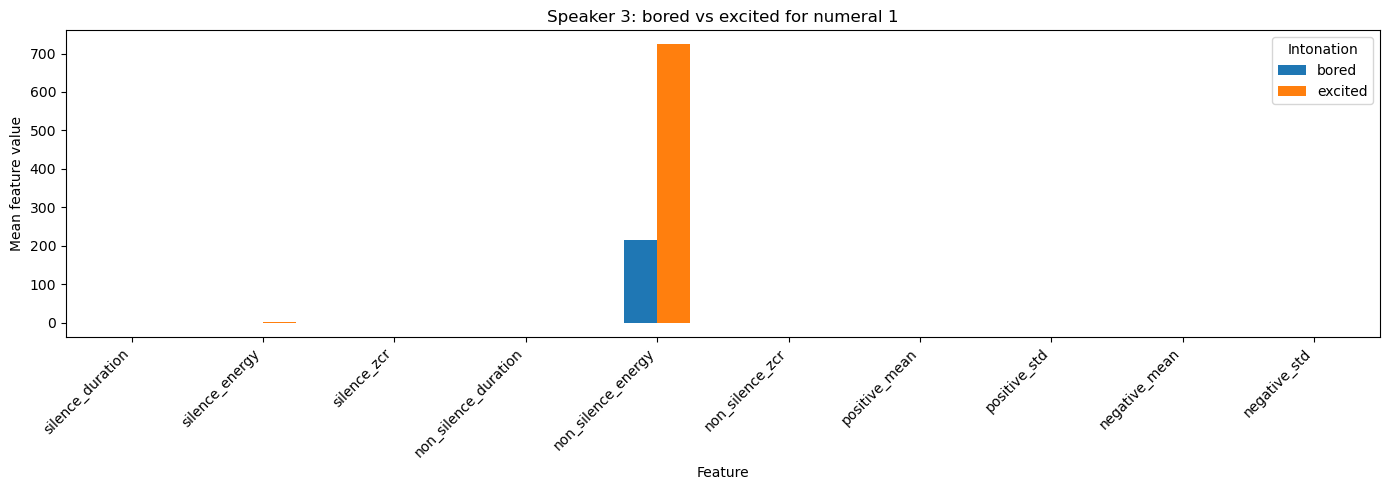

In [ ]:
speaker_labels = speaker_data[[filename_col, numeral_col, intonation_col]].copy()
speaker_labels["filename"] = speaker_labels[filename_col].astype(str).apply(os.path.basename)

speaker_features_with_labels = speaker_feature_df.merge(
    speaker_labels[["filename", numeral_col, intonation_col]],
    on="filename",
    how="left"
)

q5d_data = speaker_features_with_labels[
    (speaker_features_with_labels[numeral_col].astype(str) == "1") &
    (speaker_features_with_labels[intonation_col].astype(str).str.lower().isin(["bored", "excited"]))
].copy()

q5d_stats = q5d_data.groupby(intonation_col)[feature_columns].agg(["mean", "std"])

display(q5d_stats)

q5d_means = q5d_data.groupby(intonation_col)[feature_columns].mean()

plt.figure(figsize=(14, 5))
q5d_means.T.plot(kind="bar", figsize=(14, 5))
plt.title(f"Speaker {My_speaker}: bored vs excited for numeral 1")
plt.ylabel("Mean feature value")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Here I will be using comparative analysis from question 5 for specifically the excited and bored categories. I will be using only my speaker 3 and numeral 1. Once I filter the file, I use the 10 feature to compute standard deviation and mean. From the diagram you can see the comparison between the average for both exited and bored values. The bar graph indicates that non-silence energy is the primary apparent difference. Compared to bored speech, excited speech has a significantly higher non-silence energy. This implies that when the speaker was energised, they said the number 1 more intensely. Compared to joyful speech, bored speech has a longer average silent period.

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 6. Deeper Analysis of audio files [34 Marks]

Now that you have all the tools and skills, let's dive into deeper analysis.

As you are now familiar with the dataset - each audio file has a Numeral (e.g. 1, 2, ..., 1000000), Intonation (e.g. bored, excited, neutral, and question), and speaker number. Since you have all the audio files of one speaker, you have the flexibility to compare the features of different Numerals or different Intonations.

**Comparing two categories could go as deep as you want. You could compare only the mean of one feature, or mean and standard deviation of a selected few features, or even go further to compare more of the statistics of each feature. The important part of comparative analysis is not just to compute the different statistics but to explain the results.**


### 6.1 Compare two Numerals [10 Marks]

<br>

<div style="padding: 10px; border: 4px dashed black;">
    
**Q6A:** From all the audio files of YOUR SPEAKER, select two different Numerals (such as 1 and 2 or 100 and 1000000), and compare them using statistics. Explanation of comparative analysis is Important.

Marks for this part depend on how well you analyse and explain it. Going deeper by comparing many features is good, but it should be supported by an explaination.

</div>



### 6.2 Compare two Intonations [10 Marks]
<br>

<div style="padding: 10px; border: 4px dashed black;">

**Q6B:** From all the audio files of YOUR SPEAKER, select two different intonations (such as bored and question), and compare them using statistics. Explanation of comparative analysis is Important.

</div>




### 6.3 Compare two Speakers [14 Marks]

<br>


<div style="padding: 10px; border: 4px dashed black;">

**Q6C:** Compare your speaker with another speaker with **different nationality**. Save the comparative results as a pickle file and upload it with your submission.

Here is a modular approach to this problem:

* Step 1: Select another speaker from the dataset who has a different nationality than your speaker. For example, if your speaker is 107, then your speaker is British. Select another speaker, who is not British. Let's call this New_Speaker

* Step 2: Extract the features of all the audio files of this New_Speaker.

* Step 3: Compute the statistic of all the features of your speaker and this New_Speaker

* Step 4: Plot them for comparative analysis and explain in detail how different and how similar are these two speakers.

* Step 5: Save the comparative results as a pickle file. name it as 'Speaker_[Your Speaker Number]_[New_Speaker]_comparision.pkl'. for example, if your speaker is 107 and new speaker is 10, then file name should be Speaker_107_10_comparision.pkl'. Make sure to upload this file with your submission.

</div>

<br>

### Q6A

silence_duration                     silence_energy            \
                    mean       std    median           mean       std   
Numeral                                                                 
0               0.584688  0.186684  0.618141       2.013992  2.071268   
1               0.759935  0.205767  0.710159       1.097111  1.398545   

                  silence_zcr                     non_silence_duration  ...  \
           median        mean       std    median                 mean  ...   
Numeral                                                                 ...   
0        1.140451    0.095479  0.062043  0.107939             0.479819  ...   
1        0.346655    0.279428  0.228513  0.188643             0.313807  ...   

        positive_mean positive_std                     negative_mean  \
               median         mean       std    median          mean   
Numeral                                                                
0            0.083335     0.112730  0.044141  0.095554     -0.079119   
1            0.075492     0.100078  0.038517  0.094549     -0.049800   

                            negative_std                      
              std    median         mean       std    median  
Numeral                                                       
0        0.028078 -0.082511     0.128365  0.041542  0.115469  
1        0.024226 -0.043437     0.107852  0.044602  0.095462  

[2 rows x 30 columns]

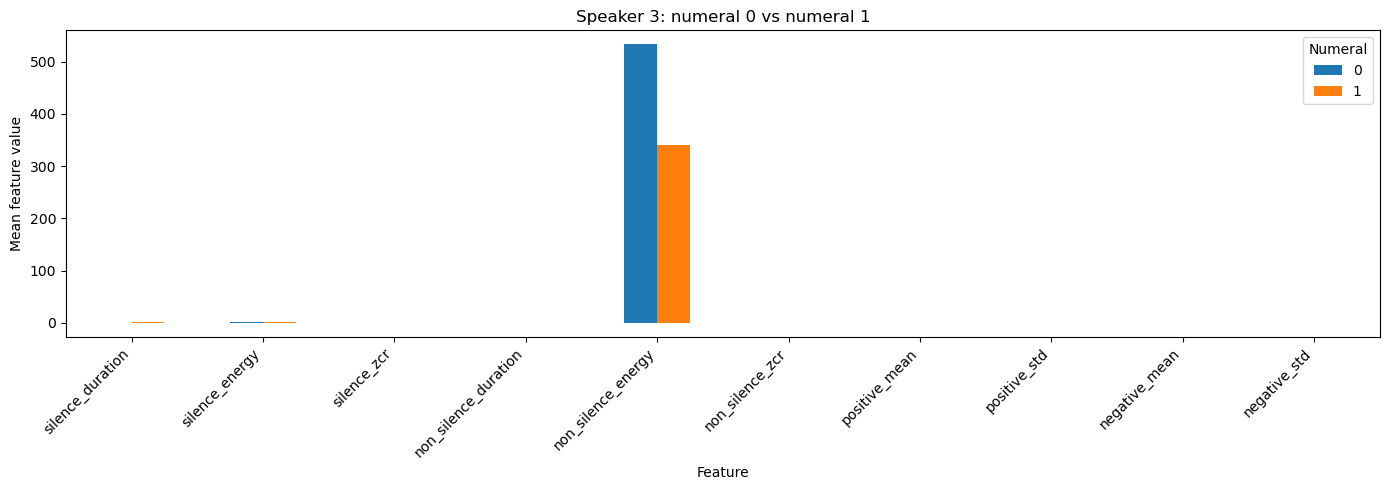

In [ ]:
available_numerals = sorted(speaker_features_with_labels[numeral_col].dropna().astype(str).unique())
numeral_a, numeral_b = available_numerals[0], available_numerals[1]

q6a_data = speaker_features_with_labels[
    speaker_features_with_labels[numeral_col].astype(str).isin([numeral_a, numeral_b])
].copy()

q6a_stats = q6a_data.groupby(numeral_col)[feature_columns].agg(["mean", "std", "median"])
display(q6a_stats)

q6a_means = q6a_data.groupby(numeral_col)[feature_columns].mean()
q6a_means.T.plot(kind="bar", figsize=(14, 5))
plt.title(f"Speaker {My_speaker}: numeral {numeral_a} vs numeral {numeral_b}")
plt.ylabel("Mean feature value")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In this section I selected and compared two numerals, 0 and 1. The statistics I will use in my comparison are mean, standard deviation and median for each of the 10 extracted audio features. This contrast illustrates whether different spoken numbers have distinct auditory characteristics for the same individual. The table shows us the statistical analysis for several factors including duration, energy, zero crossing rate, positive and negatives. The mean silence duration for numeral 1 (0.75) is higher than numeral 0 (0.58), which indicates numeral 1 takes longer to articulate and voice words than numeral 0. On the other hand, the mean silence energy is much higher in numeral 0 (2.01) than in numeral 1 (1.09), which could indicate the vocal pitch of numeral 0 is a lot louder than numeral 1. The median results are fairly similar across these three features, which shows a balanced dataset. For data visualisation I have incorporated a bar chart to compare the mean across all the features. The chart shows a significantly increased value in the non silence energy compared to the other features which could stem from a speaker phonetics for example the length of a word or the pronunciation of a word.

### Q6B

silence_duration                     silence_energy            \
                       mean       std    median           mean       std   
Intonation                                                                 
bored              1.032063  0.163179  1.055057       0.511506  0.529567   
excited            0.656997  0.087244  0.659546       4.466121  2.349731   

                     silence_zcr                     non_silence_duration  \
              median        mean       std    median                 mean   
Intonation                                                                  
bored       0.289055    0.574477  0.139229  0.572608             0.424160   
excited     4.026015    0.147939  0.043245  0.139495             0.409107   

            ... positive_mean positive_std                     negative_mean  \
            ...        median         mean       std    median          mean   
Intonation  ...                                                                
bored       ...      0.043899     0.057217  0.017796  0.055713     -0.024998   
excited     ...      0.078612     0.138183  0.018464  0.139499     -0.081039   

                               negative_std                      
                 std    median         mean       std    median  
Intonation                                                       
bored       0.007979 -0.024205     0.059585  0.017331  0.055875  
excited     0.015256 -0.079538     0.152430  0.021820  0.151605  

[2 rows x 30 columns]

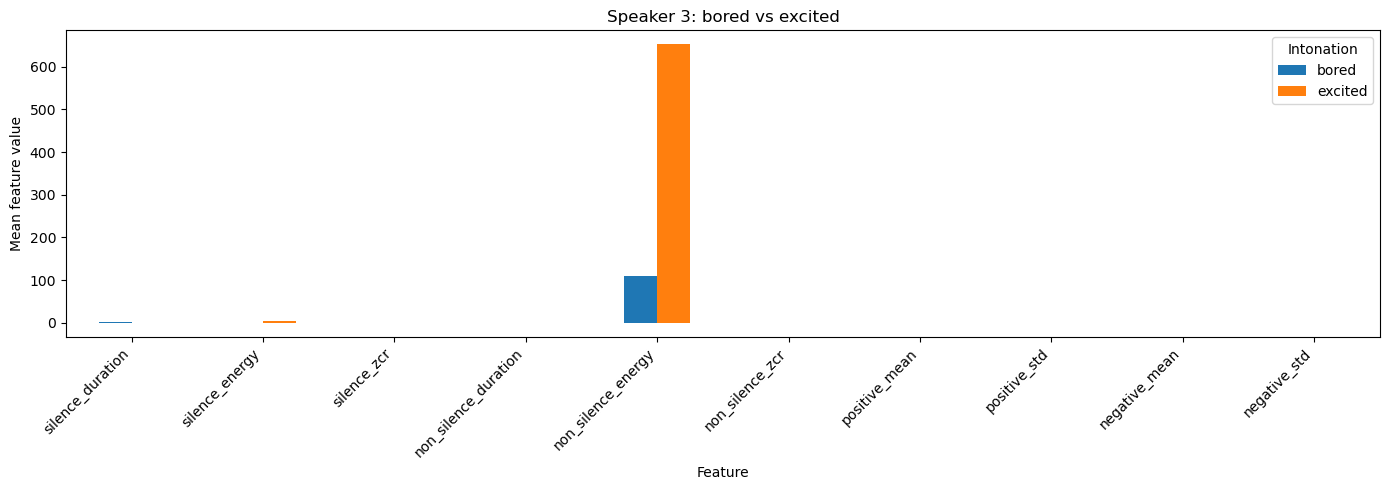

In [ ]:
available_intonations = sorted(speaker_features_with_labels[intonation_col].dropna().astype(str).unique())
intonation_a, intonation_b = available_intonations[0], available_intonations[1]

q6b_data = speaker_features_with_labels[
    speaker_features_with_labels[intonation_col].astype(str).isin([intonation_a, intonation_b])
].copy()

q6b_stats = q6b_data.groupby(intonation_col)[feature_columns].agg(["mean", "std", "median"])
display(q6b_stats)

q6b_means = q6b_data.groupby(intonation_col)[feature_columns].mean()
q6b_means.T.plot(kind="bar", figsize=(14, 5))
plt.title(f"Speaker {My_speaker}: {intonation_a} vs {intonation_b}")
plt.ylabel("Mean feature value")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In this question, I have been tasked to select two intonations and use statistics to perform comparative analysis. I have used the intonations in this case are bored and excited. Similarly, to the previous task I will use mean, median and standard deviation to compare bored and excited intonations against several features. Using the bar chart, we can see that the feature non silence energy is significantly higher in excited rather than bored, which stems from the emotion in speech as excitement correlates with a much more energetic and loud energy level and it will be visible in audio. This is also evident in the silence energy mean where bored averaged 0.51 whereas excited scored 4.46. The duration feature indicates slight difference in mean where bored is 1.03 and excited is 0.65. Apart from energy, median for both intonations is slightly similar across all the features.

### Q6C

My speaker: 3 Nationality: nan
New speaker: 0 Nationality: German


silence_duration                     silence_energy            \
                    mean       std    median           mean       std   
speaker                                                                 
0               1.365692  0.268019  1.355374       0.097963  0.050192   
3               0.793429  0.212029  0.783039       2.132878  2.376849   

                  silence_zcr                     non_silence_duration  ...  \
           median        mean       std    median                 mean  ...   
speaker                                                                 ...   
0        0.089020    0.104233  0.068991  0.099266             0.136593  ...   
3        1.269093    0.259349  0.212260  0.166479             0.408791  ...   

        positive_mean positive_std                     negative_mean  \
               median         mean       std    median          mean   
speaker                                                                
0            0.002494     0.003440  0.001326  0.003229     -0.002260   
3            0.053644     0.091189  0.040431  0.076422     -0.052628   

                            negative_std                      
              std    median         mean       std    median  
speaker                                                       
0        0.000876 -0.002069     0.004208  0.001303  0.004029  
3        0.030946 -0.041604     0.102305  0.045679  0.088135  

[2 rows x 30 columns]

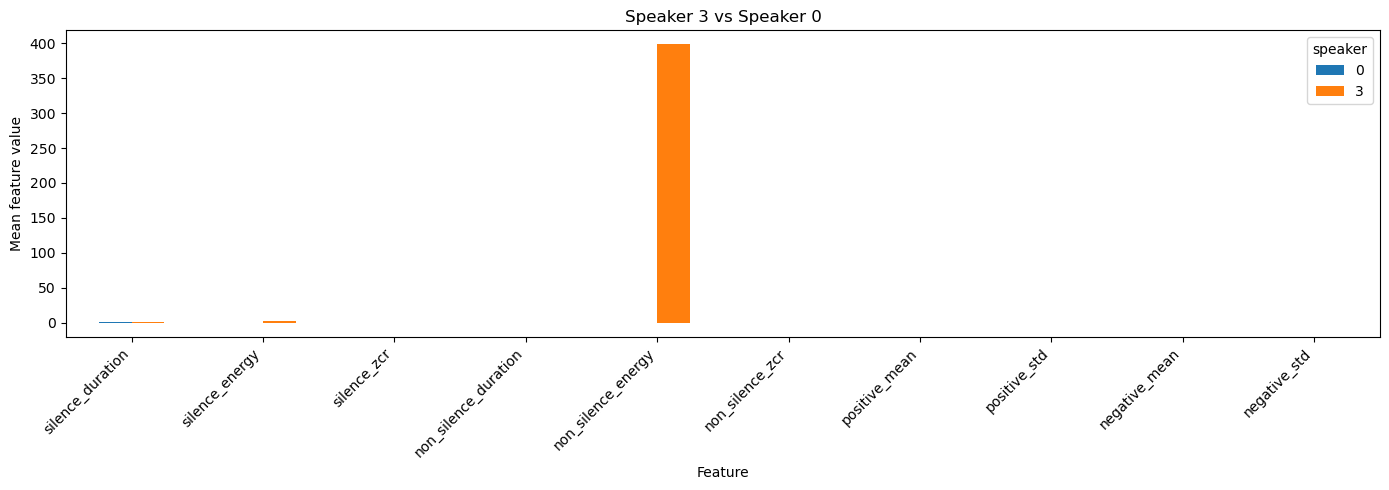

Saved: Speaker_3_0_comparision.pkl


In [ ]:
def get_speaker_nationality(speaker_number):
    """
    Return nationality for a speaker if the demographics table contains this information.
    """
    demo_speaker_col = find_column(speaker_demographics, ["speaker", "speaker_id", "speaker number", "speaker_number"])
    nat_col = find_column(speaker_demographics, ["nationality", "country", "native language"])
    row = speaker_demographics[speaker_demographics[demo_speaker_col].astype(str) == str(speaker_number)]
    if len(row) == 0:
        return None
    return row.iloc[0][nat_col]


my_nationality = get_speaker_nationality(My_speaker)

demo_speaker_col = find_column(speaker_demographics, ["speaker", "speaker_id", "speaker number", "speaker_number"])
nat_col = find_column(speaker_demographics, ["nationality", "country", "native language"])

different_nationality_speakers = speaker_demographics[
    speaker_demographics[nat_col].astype(str) != str(my_nationality)
][demo_speaker_col].astype(str).tolist()

New_Speaker = different_nationality_speakers[0]
print("My speaker:", My_speaker, "Nationality:", my_nationality)
print("New speaker:", New_Speaker, "Nationality:", get_speaker_nationality(New_Speaker))


def feature_dataframe_for_speaker(speaker_number):
    """
    Compute the 10-feature DataFrame for all files belonging to a speaker.
    """
    subset = audio_attributes[audio_attributes[speaker_col].astype(str) == str(speaker_number)].copy()
    rows = []

    for filename in subset[filename_col].astype(str).tolist():
        try:
            rows.append([os.path.basename(filename)] + compute_10_features(filename))
        except Exception as e:
            print(f"Skipping {filename}: {e}")

    df = pd.DataFrame(rows, columns=["filename"] + feature_columns)
    df["speaker"] = str(speaker_number)
    return df


new_speaker_feature_df = feature_dataframe_for_speaker(New_Speaker)

combined_speaker_df = pd.concat(
    [
        speaker_feature_df.assign(speaker=str(My_speaker)),
        new_speaker_feature_df
    ],
    ignore_index=True
)

q6c_stats = combined_speaker_df.groupby("speaker")[feature_columns].agg(["mean", "std", "median"])
display(q6c_stats)

q6c_means = combined_speaker_df.groupby("speaker")[feature_columns].mean()
q6c_means.T.plot(kind="bar", figsize=(14, 5))
plt.title(f"Speaker {My_speaker} vs Speaker {New_Speaker}")
plt.ylabel("Mean feature value")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

comparison_pickle = {
    "my_speaker": My_speaker,
    "my_nationality": my_nationality,
    "new_speaker": New_Speaker,
    "new_speaker_nationality": get_speaker_nationality(New_Speaker),
    "statistics": q6c_stats,
    "my_features": speaker_feature_df,
    "new_speaker_features": new_speaker_feature_df
}

pickle_filename = f"Speaker_{My_speaker}_{New_Speaker}_comparision.pkl"
with open(pickle_filename, "wb") as f:
    pickle.dump(comparison_pickle, f)

print("Saved:", pickle_filename)

In the last section of part 6 I will be using two speakers from different nationalities and save the results in a pickle file. I started by selecting another speaker other than my own, in this case I will compare 0 and 3. Then I used the same 10 extracted audio features for both speaker 3 and speaker 0. I used data frame to compare the data from both speakers as well as using mean, median and standard deviation to perform the comparative analysis. The mean for the feature silence duration in speaker 0 (1.36) is moderately higher than in speaker 3 (0.79), which could indicate speaker 0 speaks a lot slower than speaker 1. However the energy feature in speaker 3 (2.13) is significantly higher than in speaker 0, which is also evident in the bar chart. A discrepancy in this section is my speaker (3) as the nationality presents as nan where as speaker 0 is German. This could indicate missing values in the data or that there was no nationality recorded for speaker 3. The pickle can be found in the attachment and saved as Speaker_3_0_comparision.pkl.

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 7. Find similar audio files [10 Marks]

Now that you have created all the required functions to read audio files and extract features (10 features), and you have done many of the comparative analysis, you are ready to use all that to find similar audio files.

This is one of the fundamentals of automated systems (intelligent systems) that are used in the field of audio and speech. Some examples are Speaker Identification, Music Recognition, and Music Information retrieval.


In this section, you will write a function to identify similar audio files from the given dataset.

<div style="padding: 10px; border: 4px dashed black;">

**Q7A:** Write a function that takes a filename (such as 00003.wav) and returns 10 audio files that are similar to this. Recall Assignment 1, for similarity, we used Euclidean Distance, we will do the same here.

Here is a modular approach to this problem:


* Step 1: Extract all the 10 features of all the audio files in `MLEndSND_audiofiles` folder, select 5 features related to non-silience part of audio and save them along with the filename in a CSV file. Name it as `Audio_Features_All.csv`

* Step 2: Write a function that takes two filenames and
  * Extract 5 features from of Audio_Features_All.csv for both filenames
  * Scale them and compute Euclidean Distance between them (Recall assignment 1 for scaling and normalisation)
  * Return Euclidean Distance

  For example, given two file names, file1='00003.wav' and file2 = '06801.wav', your function should return a single float-type number, as Euclidean Distance between file1 and file2.

* Step 3: Write a function that takes one filename and computes the Euclidean Distance of this audio file to all the other audio files, including itself. Return 10 filenames of audio files that are closest to the given file. One of the names would be itself.

  For example, given one file name file1 = '00110.wav' your function should return a list of 10 filenames, one of which should be '00110.wav'


**Q7B:** Find closest 10 audio files to '00003.wav', plot all of them with audio player. Play them and see if they are really similar.


**Some of the supporting code lines are given below.**

</div>

## Q7A

In [ ]:
all_filenames = [os.path.basename(path) for path in file_list]

Audio_Features = []

for i, filename in enumerate(all_filenames):
    try:
        ten_features = compute_10_features(filename)

        five_features = [
            ten_features[3],
            ten_features[4],
            ten_features[5],
            ten_features[6],
            ten_features[8]
        ]

        fname_feature = [filename] + list(five_features)
        Audio_Features.append(fname_feature)

    except Exception as e:
        print(f"Skipping {filename}: {e}")

    if (i + 1) % 1000 == 0:
        print(f"Processed {i + 1} files")

print("Total rows:", len(Audio_Features))

/tmp/ipykernel_225/3310566983.py:20: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = scipy.io.wavfile.read(path)


Processed 1000 files
Processed 2000 files
Processed 3000 files
Processed 4000 files
Processed 5000 files
Processed 6000 files
Processed 7000 files
Processed 8000 files
Processed 9000 files
Processed 10000 files
Processed 11000 files
Processed 12000 files
Processed 13000 files
Processed 14000 files
Processed 15000 files
Processed 16000 files
Processed 17000 files
Processed 18000 files
Processed 19000 files
Processed 20000 files
Processed 21000 files
Processed 22000 files
Processed 23000 files
Processed 24000 files
Processed 25000 files
Processed 26000 files
Processed 27000 files
Processed 28000 files
Processed 29000 files
Processed 30000 files
Processed 31000 files
Processed 32000 files
Total rows: 32716


In [ ]:
D = pd.DataFrame(
    Audio_Features,
    columns=[
        "filename",
        "non_silence_duration",
        "non_silence_energy",
        "non_silence_zcr",
        "positive_mean",
        "negative_mean"
    ]
)

D.to_csv("./data/Audio_Features_All.csv", index=False)
display(D.head())

,filename,non_silence_duration,non_silence_energy,non_silence_zcr,positive_mean,negative_mean
0,00000.wav,0.383900,332.315140,0.067336,0.068806,-0.056020
1,00001.wav,0.410658,3.098274,0.044616,0.003801,-0.003542
2,00003.wav,0.636236,380.450148,0.034001,0.055231,-0.057443
3,00004.wav,0.726032,155.144398,0.127178,0.041220,-0.038152
4,00005.wav,0.316735,3.180469,0.113402,0.006801,-0.003883


In [ ]:
def closeness_audiofiles(file1, file2):
    """
    Compute Euclidean distance between two audio files using the saved 5-feature table.

    The features are standardised before computing distance so that large-scale
    features such as energy do not dominate the result.

    Parameters:
    file1, file2 : str
        Filenames to compare.

    Returns:
    float
        Euclidean distance between the two feature vectors.
    """
    D = pd.read_csv("./data/Audio_Features_All.csv")

    f1 = os.path.basename(file1)
    f2 = os.path.basename(file2)

    feature_cols = [c for c in D.columns if c != "filename"]

    X = D[feature_cols].astype(float)
    means = X.mean()
    stds = X.std().replace(0, 1)

    scaled = (X - means) / stds
    scaled.insert(0, "filename", D["filename"].astype(str))

    row1 = scaled[scaled["filename"] == f1]
    row2 = scaled[scaled["filename"] == f2]

    if len(row1) == 0:
        raise ValueError(f"{f1} not found in Audio_Features_All.csv")
    if len(row2) == 0:
        raise ValueError(f"{f2} not found in Audio_Features_All.csv")

    v1 = row1[feature_cols].iloc[0].values
    v2 = row2[feature_cols].iloc[0].values

    euc_dist = float(np.sqrt(np.sum((v1 - v2) ** 2)))
    return euc_dist


print("Example distance:", closeness_audiofiles("00003.wav", "06801.wav"))

Example distance: 3.8462619471245825


In [ ]:
def closest_10_audiofiles(filename):
    """
    Find the 10 closest audio files to a given file using Euclidean distance.

    Parameters:
    filename : str
        Query audio filename.

    Returns:
    list[str]
        Ten filenames with the smallest distances to the query file.
    """
    D = pd.read_csv("./data/Audio_Features_All.csv")
    query = os.path.basename(filename)

    distances = []
    for other_file in D["filename"].astype(str):
        dist = closeness_audiofiles(query, other_file)
        distances.append((other_file, dist))

    distances = sorted(distances, key=lambda item: item[1])
    list_10_closest = [name for name, dist in distances[:10]]
    return list_10_closest


closest_files = closest_10_audiofiles("00003.wav")
closest_files

['00003.wav',
 '46804.wav',
 '00591.wav',
 '17552.wav',
 '41731.wav',
 '33494.wav',
 '03736.wav',
 '25033.wav',
 '29801.wav',
 '19270.wav']

In this portion of the project, I will construct functions to locate comparable audio recordings inside the same dataset. Using five characteristics associated with the non-silence portion of the signal, non silence length, non-silence zero crossing rate, non silence energy, positive mean, and negative mean, I made a feature table for every audio file. I chose these because they are more beneficial for comparison than background quiet because the non-silent portion includes the spoken numeral. I standardised the features before computing the Euclidean distance to prevent characteristics with wider numerical ranges from controlling the distance. The files that are closest to the query file are those that have the minimum Euclidean distances.

## Q7B

Closest 10 files to 00003.wav:
['00003.wav', '46804.wav', '00591.wav', '17552.wav', '41731.wav', '33494.wav', '03736.wav', '25033.wav', '29801.wav', '19270.wav']


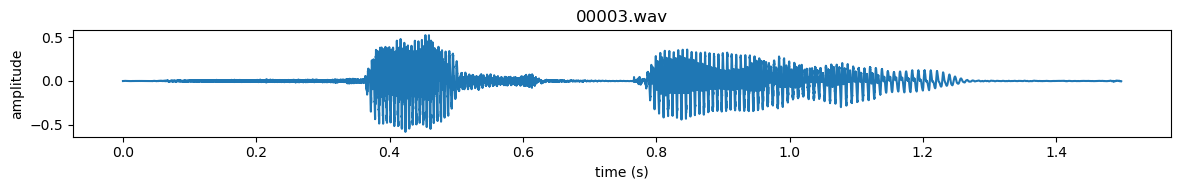

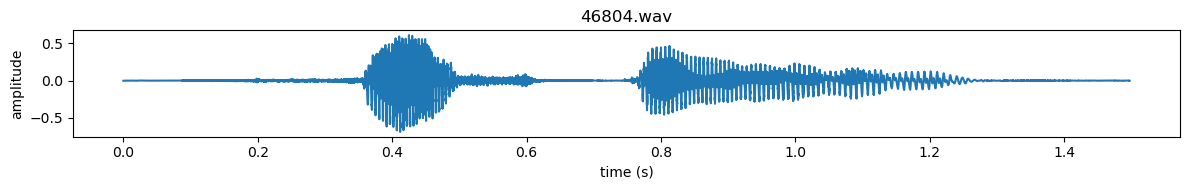

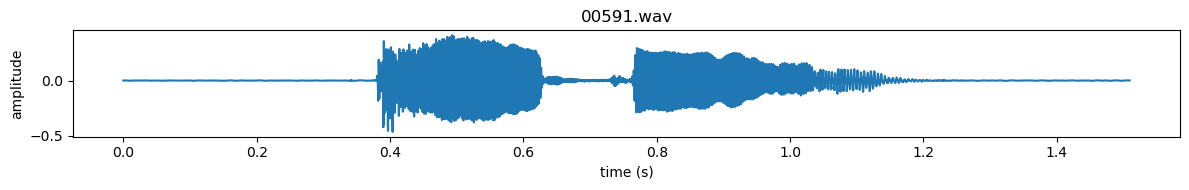

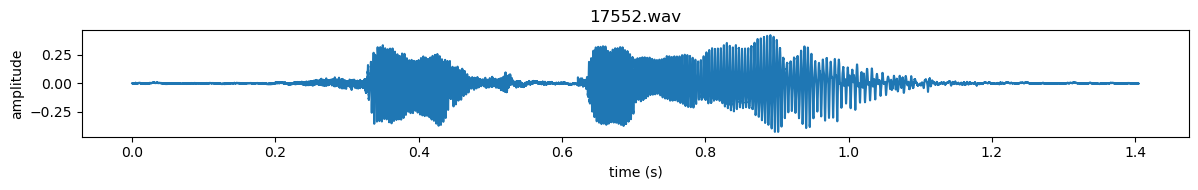

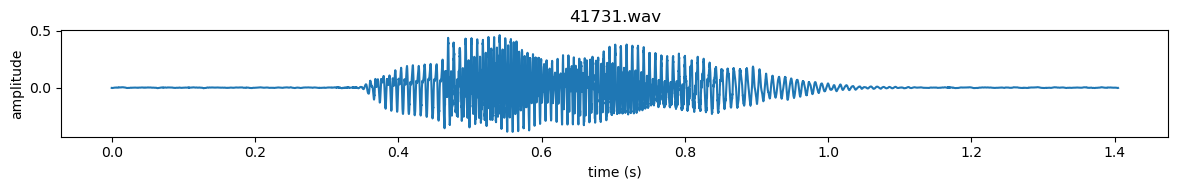

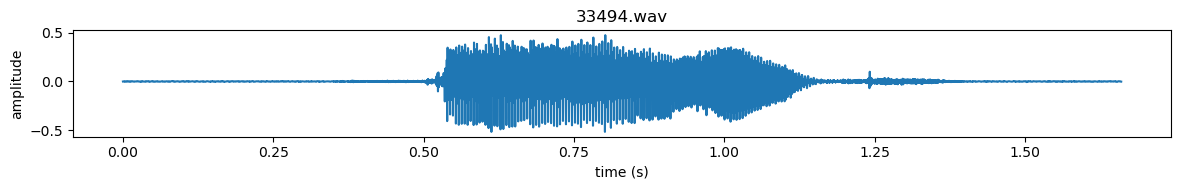

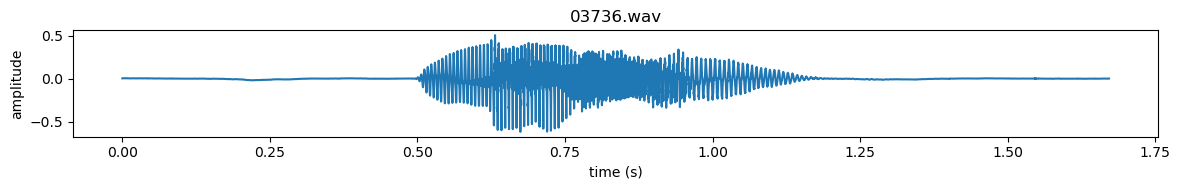

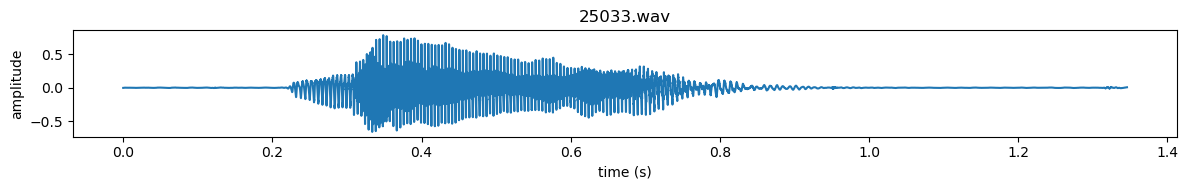

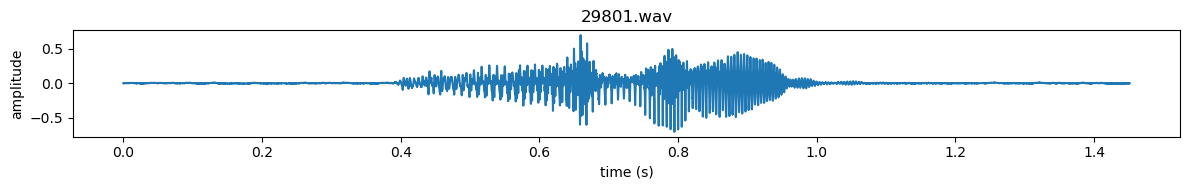

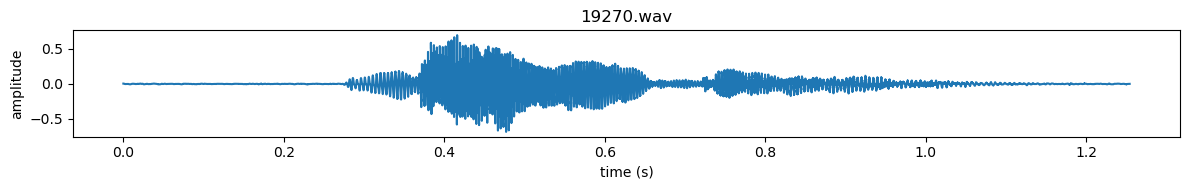

In [ ]:
closest_files = closest_10_audiofiles("00003.wav")
print("Closest 10 files to 00003.wav:")
print(closest_files)

for fname in closest_files:
    fs, x = read_audio_file(fname)
    t = np.arange(len(x)) / fs

    plt.figure(figsize=(12, 2))
    plt.plot(t, x)
    plt.title(fname)
    plt.xlabel("time (s)")
    plt.ylabel("amplitude")
    plt.tight_layout()
    plt.show()

    display(IPython.display.Audio(x, rate=fs))

I plotted and played the ten files that were closest to 00003.wav. The Euclidean distance approach makes data with similar energy levels, duration and waveform patterns seem closer. However, the approach may not always accurately mimic human listening because it is just based on five basic features. Even though the numerical properties of some files are same, they may sound different. Features, like  MFCC features or spectrogram, could be used by a more complex system, but the existing method works well for this task because it uses the necessary Euclidean distance method.

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 8. Submission Instructions

To tick the boxes below, double click on the segment, and edit '[ ]' to '[x]'

<div style="padding: 10px; border: 2px solid blue;">
    
Before uploading your submission to QMplus, make sure that (checklist):

* [x] Your name and QMUL ID are added at the top of the Jupyter-notebook.
* [x] All the figures and code are saved.
* [x] Your solution Jupyter-notebook and result files ( CSV file from Q5.2 and pickle file from Q6.3) are in the same folder.
* [x] Excluding data, compress them to a Zip file and rename it as [Your_Name]_[QMUL_ID]_Assignment2.zip.
* [x] **Make sure to exclude data folder which includes all the audio files**, otherwise your submission file will be very large.
* [x] Do not include Spoken Numerals Dataset in your zip file, we will use the original Dataset to test your code and solution.
* [x] Upload it using the link provided on QMPlus.
* [x] You are allowed to submit one Zip file only, which should contain your Jupyter-Notebook file and result files ( CSV file from Q5.2 and pickle file from Q6.3).
* **Deadline** to submit your assignment is **Friday (01 of May of 2026), at 17:00 (5:00PM)**.

</div>


<div style="padding: 10px; border: 2px solid black;">
    
**Academic honesty declaration**
* [x] I declare that I have completed this assignment on my own.
      
Your Name  Shamsa Abdulkadir Sheikh Mao
</div>